In [335]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

## Data Importing

In [336]:
file_path = "./data/Energy_consumption.csv"


df = pd.read_csv(Path(file_path))
df.head(5)

,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,EnergyConsumption
0,1/1/2022 0:00,25.139433,43.431581,1565.693999,5,On,Off,2.774699,Monday,No,75.364373
1,1/1/2022 1:00,27.731651,54.225919,1411.064918,1,On,On,21.831384,Saturday,No,83.401855
2,1/1/2022 2:00,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,Sunday,No,78.270888
3,1/1/2022 3:00,20.080469,50.371637,1452.316318,1,Off,On,8.623447,Wednesday,No,56.519850
4,1/1/2022 4:00,23.097359,51.401421,1094.130359,9,On,Off,3.071969,Friday,No,70.811732


In [337]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Timestamp          1000 non-null   object 
 1   Temperature        1000 non-null   float64
 2   Humidity           1000 non-null   float64
 3   SquareFootage      1000 non-null   float64
 4   Occupancy          1000 non-null   int64  
 5   HVACUsage          1000 non-null   object 
 6   LightingUsage      1000 non-null   object 
 7   RenewableEnergy    1000 non-null   float64
 8   DayOfWeek          1000 non-null   object 
 9   Holiday            1000 non-null   object 
 10  EnergyConsumption  1000 non-null   float64
dtypes: float64(5), int64(1), object(5)
memory usage: 86.1+ KB


## Data Preprocessing

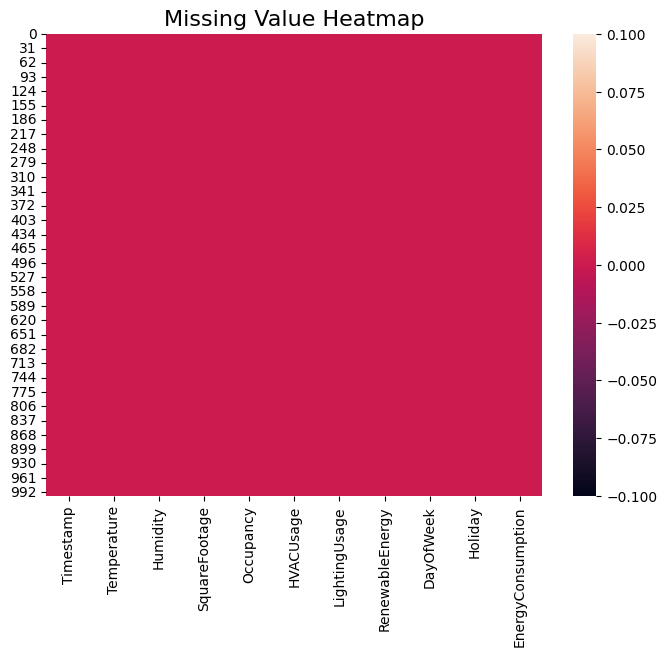

In [338]:
plt.figure(figsize=(8,6))
sns.heatmap(df.isna())
plt.title("Missing Value Heatmap", fontsize=16)
plt.show()

In [339]:
#Date time conversion
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
#Time feature
df['Num_DayOfWeek'] = df['Timestamp'].dt.dayofweek
df["DayOfWeek"] = df["Timestamp"].dt.day_name()
df['Holiday'] = df['Num_DayOfWeek'].apply(lambda x: "Yes" if x >= 5 else "No")

df['hour'] = df['Timestamp'].dt.hour
df['month'] = df['Timestamp'].dt.month
df

,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,EnergyConsumption,Num_DayOfWeek,hour,month
0,2022-01-01 00:00:00,25.139433,43.431581,1565.693999,5,On,Off,2.774699,Saturday,Yes,75.364373,5,0,1
1,2022-01-01 01:00:00,27.731651,54.225919,1411.064918,1,On,On,21.831384,Saturday,Yes,83.401855,5,1,1
2,2022-01-01 02:00:00,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,Saturday,Yes,78.270888,5,2,1
3,2022-01-01 03:00:00,20.080469,50.371637,1452.316318,1,Off,On,8.623447,Saturday,Yes,56.519850,5,3,1
4,2022-01-01 04:00:00,23.097359,51.401421,1094.130359,9,On,Off,3.071969,Saturday,Yes,70.811732,5,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2022-02-11 11:00:00,28.619382,48.850160,1080.087000,5,Off,Off,21.194696,Friday,No,82.306692,4,11,2
996,2022-02-11 12:00:00,23.836647,47.256436,1705.235156,4,Off,On,25.748176,Friday,No,66.577320,4,12,2
997,2022-02-11 13:00:00,23.005340,48.720501,1320.285281,6,Off,On,0.297079,Friday,No,72.753471,4,13,2
998,2022-02-11 14:00:00,25.138365,31.306459,1309.079719,3,On,Off,20.425163,Friday,No,76.950389,4,14,2


## Data Exploratory

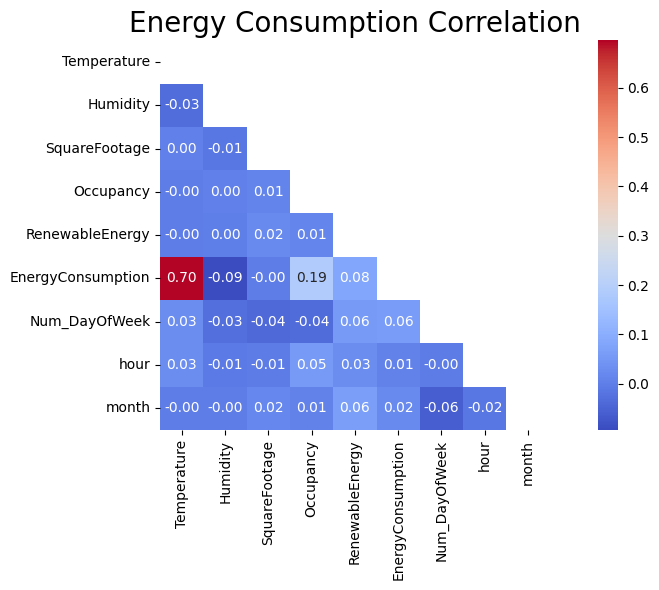

In [340]:
plt.figure(figsize=(10, 6))



corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, 
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    square=True,
    mask=mask
    )
plt.title("Energy Consumption Correlation", fontsize=20)
plt.tight_layout()
plt.show()


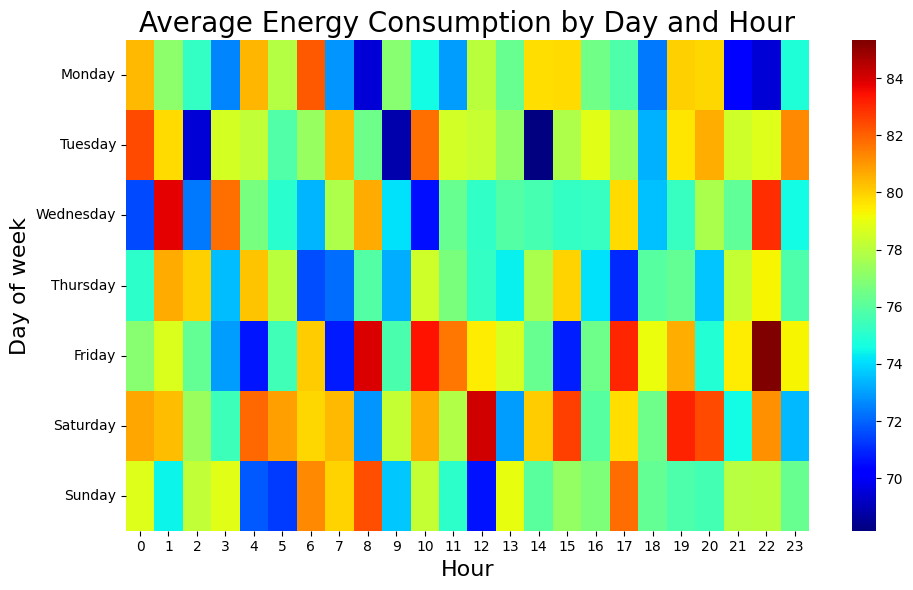

In [341]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

heatmap = df.pivot_table(
    index='DayOfWeek',
    columns='hour',
    values='EnergyConsumption',
    aggfunc='mean'
).reindex(day_order)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap, cmap="jet")
plt.title("Average Energy Consumption by Day and Hour", fontsize=20)
plt.ylabel("Day of week", fontsize=16)
plt.xlabel("Hour", fontsize=16)
plt.tight_layout()
plt.show()

C:\Users\LC\AppData\Local\Temp\ipykernel_111552\4212269771.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='DayOfWeek', y='EnergyConsumption', order=day_order, legend=False, palette='viridis')


Text(0, 0.5, 'Energy Consumption')

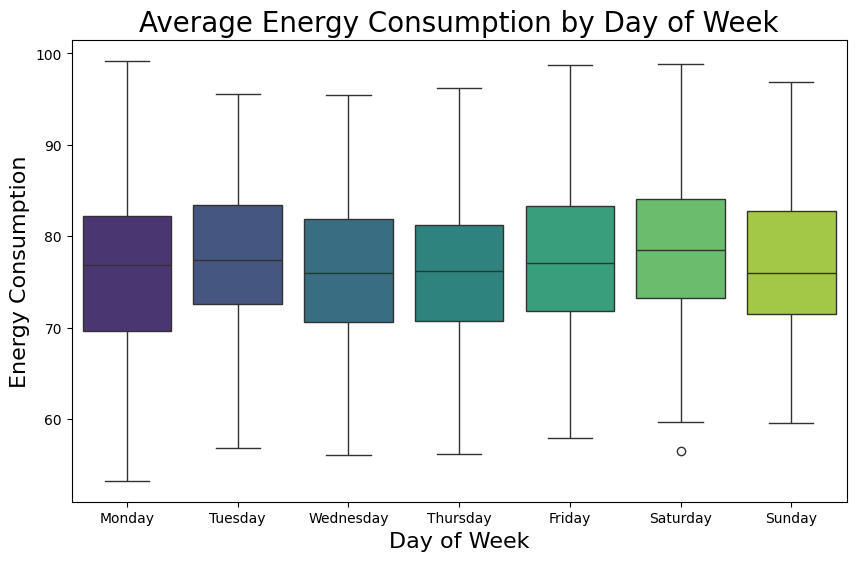

In [342]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='DayOfWeek', y='EnergyConsumption', order=day_order, legend=False, palette='viridis')
plt.title("Average Energy Consumption by Day of Week", fontsize=20)
plt.xlabel("Day of Week", fontsize=16)
plt.ylabel("Energy Consumption", fontsize=16)

Text(0.5, 0, 'Temperature')

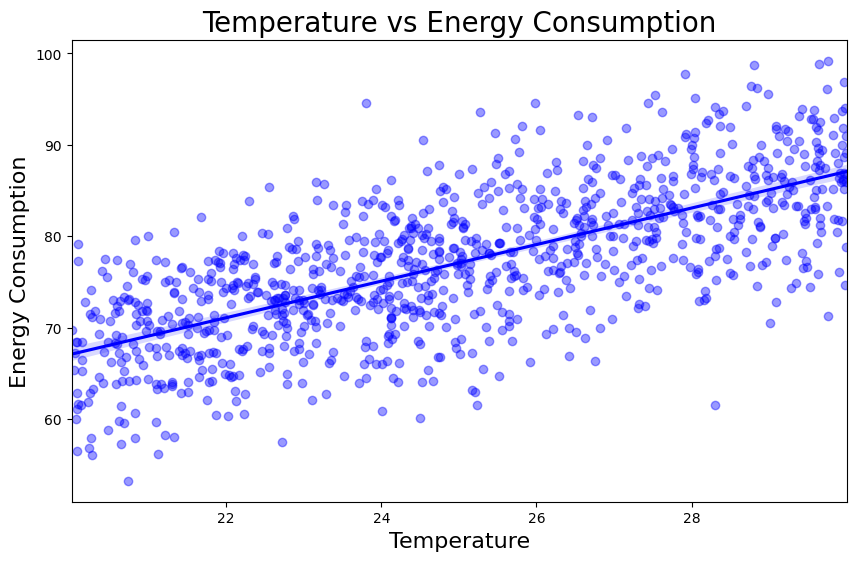

In [343]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Temperature', y='EnergyConsumption', scatter_kws={"alpha": 0.4}, color='blue')
plt.title("Temperature vs Energy Consumption", fontsize=20)
plt.xlim(df['Temperature'].min(), df["Temperature"].max())
plt.ylabel("Energy Consumption", fontsize=16)
plt.xlabel("Temperature", fontsize=16)

Text(0.5, 0, 'Humidity ')

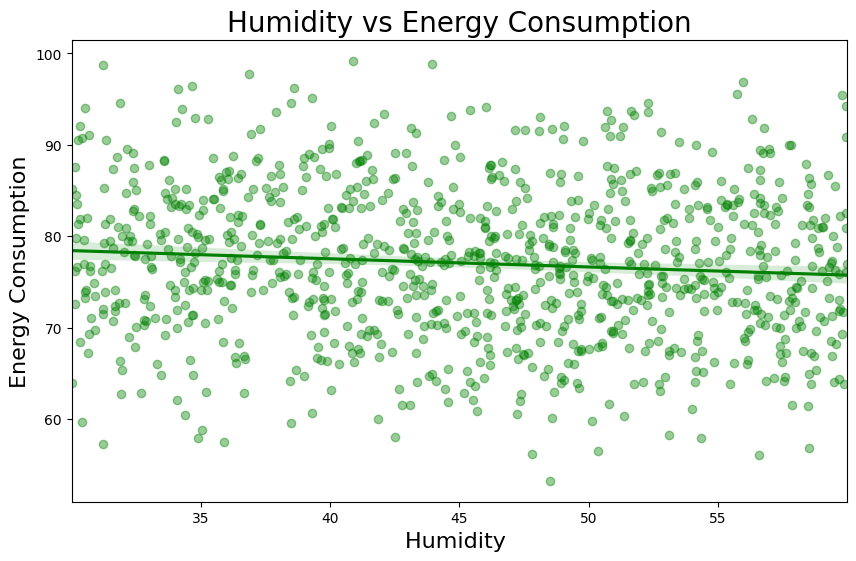

In [344]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Humidity', y='EnergyConsumption', scatter_kws={"alpha": 0.4}, color='green')
plt.title("Humidity vs Energy Consumption", fontsize=20)
plt.xlim(df['Humidity'].min(), df["Humidity"].max())
plt.ylabel("Energy Consumption", fontsize=16)
plt.xlabel("Humidity ", fontsize=16)

In [345]:
def create_features(df):
    df = df.copy()

    df["Timestamp"] = pd.to_datetime(df["Timestamp"])

    df["Num_DayOfWeek"] = df["Timestamp"].dt.dayofweek
    df["DayOfWeek"] = df["Timestamp"].dt.day_name()
    df["Holiday"] = df["Num_DayOfWeek"].apply(lambda x: "Yes" if x >= 5 else "No")
    df["hour"] = df["Timestamp"].dt.hour
    df["month"] = df["Timestamp"].dt.month

    df = df.sort_values("Timestamp").copy()

    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

    df = pd.get_dummies(
        df,
        columns=["HVACUsage", "LightingUsage", "DayOfWeek", "Holiday"],
        drop_first=True
    )

    df["lag_3"] = df["EnergyConsumption"].shift(3)
    df["lag_6"] = df["EnergyConsumption"].shift(6)
    df["lag_12"] = df["EnergyConsumption"].shift(12)
    df["lag_48"] = df["EnergyConsumption"].shift(48)
    df["lag_168"] = df["EnergyConsumption"].shift(168)

    df["rolling_mean_6"] = df["EnergyConsumption"].shift(1).rolling(6).mean()
    df["rolling_mean_12"] = df["EnergyConsumption"].shift(1).rolling(12).mean()
    df["rolling_mean_24"] = df["EnergyConsumption"].shift(1).rolling(24).mean()
    df["rolling_mean_168"] = df["EnergyConsumption"].shift(1).rolling(168).mean()

    df["rolling_std_24"] = df["EnergyConsumption"].shift(1).rolling(24).std()
    df["rolling_max_24"] = df["EnergyConsumption"].shift(1).rolling(24).max()
    df["rolling_min_24"] = df["EnergyConsumption"].shift(1).rolling(24).min()

    df = df.dropna()

    return df



In [346]:
data = create_features(df)
data.head(5)

,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,RenewableEnergy,EnergyConsumption,Num_DayOfWeek,hour,month,...,lag_12,lag_48,lag_168,rolling_mean_6,rolling_mean_12,rolling_mean_24,rolling_mean_168,rolling_std_24,rolling_max_24,rolling_min_24
168,2022-01-08 00:00:00,25.714735,42.298665,1999.204208,1,29.565863,75.614982,5,0,1,...,82.962933,76.936453,75.364373,82.658611,80.175536,78.266218,76.078955,7.007576,95.070962,67.637641
169,2022-01-08 01:00:00,20.914792,31.710094,1486.780868,5,4.306860,71.789647,5,1,1,...,77.220086,64.595337,83.401855,79.415947,79.563207,78.326048,76.080447,6.977227,95.070962,67.637641
170,2022-01-08 02:00:00,25.205341,48.649901,1533.208172,3,4.054743,63.008158,5,2,1,...,71.131062,81.109019,78.270888,78.080847,79.110670,78.404153,76.011327,6.888913,95.070962,67.637641
171,2022-01-08 03:00:00,25.976524,38.484153,1595.427693,4,16.205204,94.550625,5,3,1,...,69.272222,70.257743,56.519850,75.460456,78.433761,77.213061,75.920477,6.979847,95.070962,63.008158
172,2022-01-08 04:00:00,27.726414,53.339179,1751.722623,2,21.647358,83.576831,5,4,1,...,82.236848,65.981422,70.811732,76.980947,80.540295,77.980214,76.146851,7.818131,95.070962,63.008158


## Training

In [347]:
models = {
    "Ridge": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("regressor", Ridge())
        ]),
        "params": {
            "regressor__alpha": [0.01, 0.1, 1, 10, 100]
        }
    },

    "Lasso": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("regressor", Lasso(max_iter=10000))
        ]),
        "params": {
            "regressor__alpha": [0.001, 0.01, 0.1, 1, 10]
        }
    },

    "ElasticNet": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("regressor", ElasticNet(max_iter=10000))
        ]),
        "params": {
            "regressor__alpha": [0.001, 0.01, 0.1, 1, 10],
            "regressor__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
        }
    },

    "DecisionTree": {
        "model": DecisionTreeRegressor(random_state=42),
        "params": {
            "max_depth": [3, 5, 7, 10, 15, None],
            "min_samples_split": [2, 5, 10, 20],
            "min_samples_leaf": [1, 2, 5, 10]
        }
    },
    "RandomForestRegressor": {
        "model": RandomForestRegressor(random_state=42, n_jobs=-1),
        "params": {
            "n_estimators": [100, 200, 300 , 500],
            "max_depth": [5, 10, 15, 20, None],
            "min_samples_split": [2, 5, 10],
            "max_features": ['sqrt', 'log2', None]
        }
    },

    "ExtraTreesRegressor": {
        "model": ExtraTreesRegressor(random_state=42, n_jobs=-1),
        "params": {
            "n_estimators": [100, 200, 300, 500],
            "max_depth": [5, 10, 15, 20, None],
            "min_samples_split": [2, 5, 10],
            "max_features": ['sqrt', 'log2', None]
        }
    },

    "GradientBoosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "params": {
            "n_estimators": [100, 200, 300],
            "learning_rate": [0.01, 0.03, 0.05, 0.1],
            "max_depth": [2, 3, 4, 5],
            "subsample": [0.7, 0.8, 0.9 , 1.0]
        }
    },

    "HistGradientBoosting": {
        "model": HistGradientBoostingRegressor(random_state=42),
        "params": {
            "learning_rate": [0.01, 0.03, 0.05, 0.1],
            "max_iter": [100, 200, 300, 500],
            "max_leaf_nodes": [15, 31, 63],
            "l2_regularization": [0, 0.01, 0.1, 1]
        }
    },

    "SVR": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("regressor", SVR())
        ]),
        "params": {
            "regressor__C": [1, 10, 100],
            "regressor__epsilon": [0.01, 0.1, 1],
            "regressor__gamma": ['scale', 'auto']
        }
    }
}

In [348]:
split_idx = int(len(data) * 0.8)

train = data.iloc[:split_idx]
test = data.iloc[split_idx:]

X_train = train.drop(['EnergyConsumption', 'Timestamp'], axis=1)
y_train = train['EnergyConsumption']

X_test = test.drop(['EnergyConsumption', 'Timestamp'], axis=1)
y_test = test['EnergyConsumption']

tscv = TimeSeriesSplit(n_splits=5)

best_model = None
best_model_name = None
best_rmse = float("inf")

In [349]:
results = []
for name, config in models.items():

    print(f"Model Training: {name}")

    search = RandomizedSearchCV(
        estimator=config["model"],
        param_distributions=config["params"],
        n_iter=20,
        scoring="neg_root_mean_squared_error",
        cv=tscv,
        random_state=42,
        n_jobs=-1
                )
    
    search.fit(X_train, y_train)
    rmse = -search.best_score_

    results.append({
        "Model": name,
        "Best RMSE": rmse,
        "Best Params": search.best_params_
    })

    if rmse < best_rmse:
        best_rmse = rmse
        best_model = search.best_estimator_
        best_model_name = name

y_pred = best_model.predict(X_test)

evaluation_metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2 Score"],
    "Value": [
        mean_absolute_error(y_test, y_pred),
        root_mean_squared_error(y_test, y_pred),
        r2_score(y_test, y_pred)
    ]
})


joblib.dump(best_model, "model.joblib")
joblib.dump(list(X_train.columns), "feature_columns.joblib")
joblib.dump(best_model_name, "model_name.joblib")

print(f"Saved best model: {best_model_name}")
print(f"Best RMSE: {best_rmse:.4f}")

results_df = pd.DataFrame(results).sort_values("Best RMSE", ascending=True)


Model Training: Ridge


c:\Users\LC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 5 is smaller than n_iter=20. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Model Training: Lasso


c:\Users\LC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 5 is smaller than n_iter=20. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Model Training: ElasticNet
Model Training: DecisionTree
Model Training: RandomForestRegressor
Model Training: ExtraTreesRegressor
Model Training: GradientBoosting
Model Training: HistGradientBoosting
Model Training: SVR


c:\Users\LC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 18 is smaller than n_iter=20. Running 18 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Saved best model: Lasso
Best RMSE: 5.5407


## Evaluation

C:\Users\LC\AppData\Local\Temp\ipykernel_111552\2691996259.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_plot, x="Best RMSE", y="Model", palette="coolwarm")


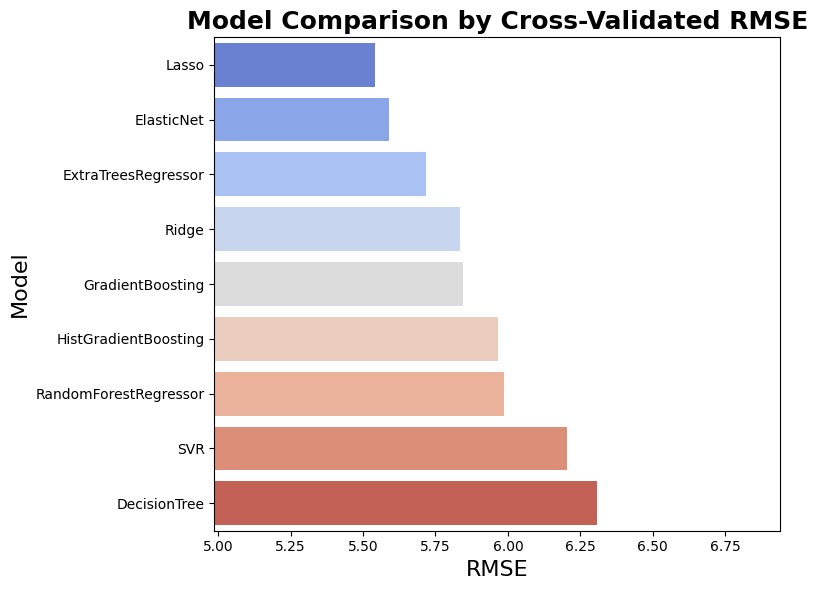

In [ ]:
results_plot = results_df.sort_values("Best RMSE").copy()

plt.figure(figsize=(8, 6))

sns.barplot(
    data=results_plot, 
    x="Best RMSE", 
    y="Model", 
    palette="coolwarm"
)

plt.title("Model Comparison by Cross-Validated RMSE", fontsize=18, fontweight='bold')
plt.xlabel("RMSE", fontsize=16)
plt.ylabel("Model", fontsize=16)
plt.tight_layout()
plt.xlim(results_plot["Best RMSE"].min()*0.9, results_plot["Best RMSE"].max()*1.1)
plt.show()

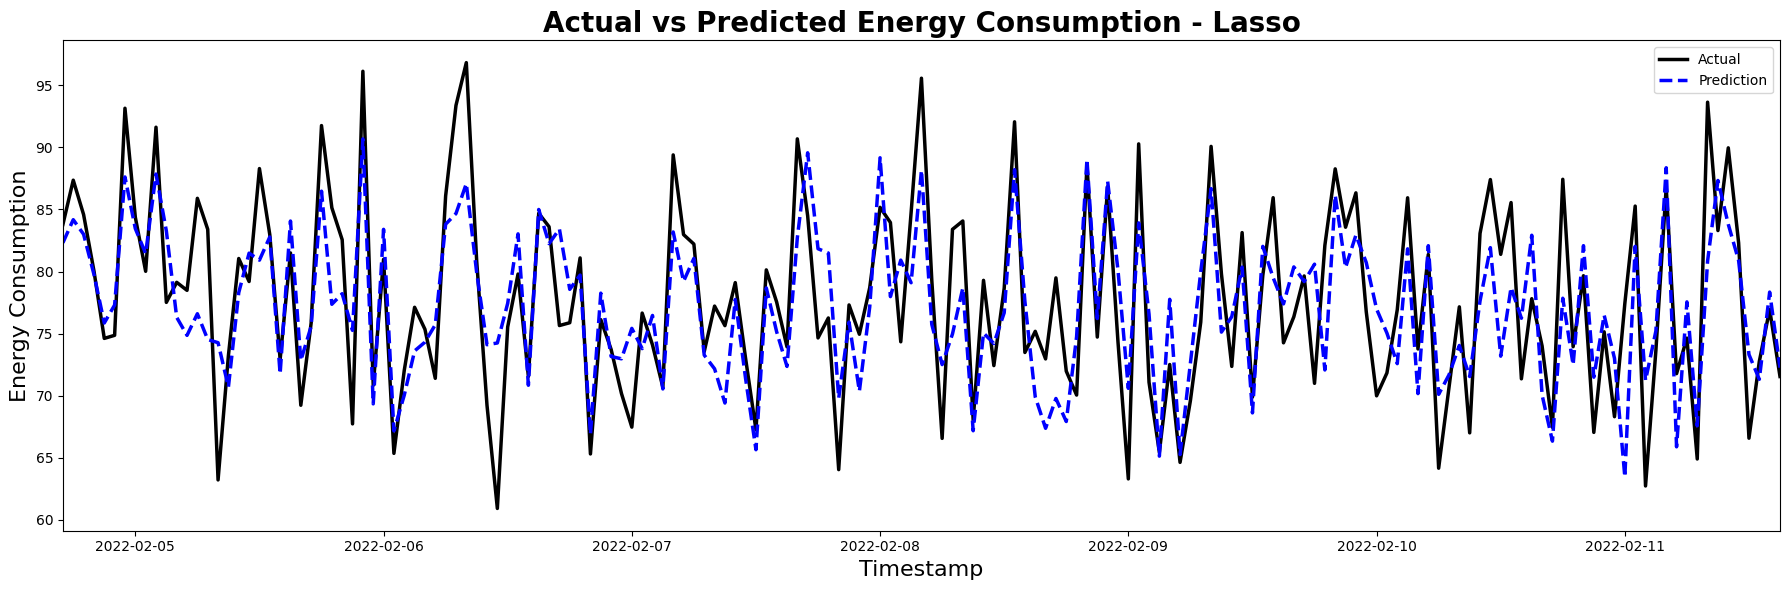

In [372]:
eval_df = test.copy()
eval_df["Prediction"] = y_pred
eval_df["Error"] = eval_df["EnergyConsumption"] - eval_df["Prediction"]
eval_df["Absolute_Error"] = np.abs(eval_df["Error"])

plt.figure(figsize=(18, 6))
sns.lineplot(
    data=eval_df,
    x="Timestamp",
    y="EnergyConsumption",
    label="Actual",
    linewidth=2.5,
    color='black'
)

sns.lineplot(
    data=eval_df,
    x="Timestamp",
    y="Prediction",
    label="Prediction",
    linewidth=2.5,
    markers="o",
    markersize=10,
    linestyle='--',
    color='blue'
)

plt.title(f"Actual vs Predicted Energy Consumption - {best_model_name}", fontsize=20, fontweight='bold')
plt.xlabel("Timestamp", fontsize=16)
plt.ylabel("Energy Consumption", fontsize=16)
plt.xlim(eval_df['Timestamp'].min(), eval_df['Timestamp'].max())
plt.legend()
plt.tight_layout()
plt.show()

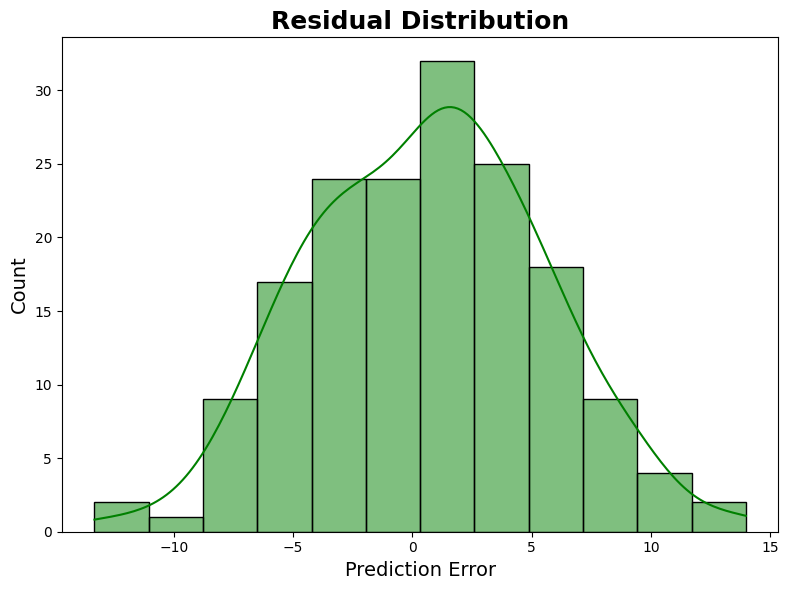

In [382]:
plt.figure(figsize=(8, 6))
sns.histplot(
    eval_df["Error"], 
    kde=True,
    color='green',
)
plt.title("Residual Distribution", fontsize=18, fontweight='bold')
plt.xlabel("Prediction Error", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.tight_layout()
plt.show()